In [ ]:
# ============================================
# QUIZ 3 & 4: COMPLETE CRYPTOCURRENCY DASHBOARD
# Student: Wareesha Rehman
# Course: Advanced Data Visualization and Graph Analytics
# Assignment: Quiz 3 (Dashboard) + Quiz 4 (ML Forecasting)
# ============================================

# STEP 1: Install and Import Libraries
!pip install plotly ipywidgets -q

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
from datetime import datetime, timedelta
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# For interactive widgets
from ipywidgets import interact, Dropdown, IntSlider, VBox, HBox, Output

print("="*60)
print("QUIZ 3 & 4: CRYPTOCURRENCY MARKET DASHBOARD WITH ML FORECASTING")
print(f"Student: Wareesha Rehman")
print(f"Date: {datetime.now().strftime('%Y-%m-%d')}")
print("="*60)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 42.7 MB/s eta 0:00:00
QUIZ 3 & 4: CRYPTOCURRENCY MARKET DASHBOARD WITH ML FORECASTING
Student: Wareesha Rehman
Date: 2026-06-03


In [ ]:
# ============================================
# PART 1: DATA IMPORT (Module 1)
# ============================================

print("\n" + "="*60)
print("PART 1: DATA IMPORT FROM WEB (Live API)")
print("="*60)

# API URL for top 50 cryptocurrencies
url = "https://api.coingecko.com/api/v3/coins/markets?vs_currency=usd&order=market_cap_desc&per_page=50&page=1&sparkline=false"

print("🌐 Fetching live data from CoinGecko API...")
response = requests.get(url)
data = response.json()

# Convert to DataFrame
df = pd.DataFrame(data)

# Select relevant columns
df = df[['name', 'symbol', 'current_price', 'market_cap', 'total_volume',
         'price_change_percentage_24h', 'high_24h', 'low_24h', 'last_updated']]

print(f"✅ Loaded {len(df)} cryptocurrencies")
print(f"📅 Last updated: {df['last_updated'].iloc[0]}")
print(f"🔗 Data Source: CoinGecko API (https://www.coingecko.com/en/api)")


PART 1: DATA IMPORT FROM WEB (Live API)
🌐 Fetching live data from CoinGecko API...
✅ Loaded 50 cryptocurrencies
📅 Last updated: 2026-06-03T15:17:55.883Z
🔗 Data Source: CoinGecko API (https://www.coingecko.com/en/api)


In [ ]:
# ============================================
# PART 2: DATA TRANSFORMATION (Module 2)
# ============================================

print("\n" + "="*60)
print("PART 2: DATA TRANSFORMATION AND CLEANING")
print("="*60)

# Handle missing values
print(f"Missing values before cleaning: {df.isnull().sum().sum()}")
df = df.dropna(subset=['current_price', 'market_cap'])
print(f"Missing values after cleaning: {df.isnull().sum().sum()}")

# Create derived columns (Feature Engineering)
df['market_cap_billions'] = (df['market_cap'] / 1e9).round(2)
df['volume_billions'] = (df['total_volume'] / 1e9).round(2)
df['price_change_absolute'] = df['high_24h'] - df['low_24h']
df['volatility'] = (df['price_change_absolute'] / df['current_price']) * 100
df['market_dominance'] = (df['market_cap'] / df['market_cap'].sum()) * 100

# Format price
df['current_price_formatted'] = df['current_price'].apply(lambda x: f"${x:,.2f}")

# Add category for filtering (Slicer requirement)
def categorize_market_cap(cap_billions):
    if cap_billions > 100:
        return 'Large Cap (>$100B)'
    elif cap_billions > 10:
        return 'Mid Cap ($10B-$100B)'
    elif cap_billions > 1:
        return 'Small Cap ($1B-$10B)'
    else:
        return 'Micro Cap (<$1B)'

df['market_cap_category'] = df['market_cap_billions'].apply(categorize_market_cap)

print("✅ Data transformation completed")
print(f"📊 New features created: market_cap_billions, volatility, market_dominance, market_cap_category")
print(f"📊 Dataset shape: {df.shape}")


PART 2: DATA TRANSFORMATION AND CLEANING
Missing values before cleaning: 0
Missing values after cleaning: 0
✅ Data transformation completed
📊 New features created: market_cap_billions, volatility, market_dominance, market_cap_category
📊 Dataset shape: (50, 16)


In [ ]:
# ============================================
# PART 2: DATA TRANSFORMATION (Module 2)
# ============================================

print("\n" + "="*60)
print("PART 2: DATA TRANSFORMATION AND CLEANING")
print("="*60)

# Handle missing values
print(f"Missing values before cleaning: {df.isnull().sum().sum()}")
df = df.dropna(subset=['current_price', 'market_cap'])
print(f"Missing values after cleaning: {df.isnull().sum().sum()}")

# Create derived columns (Feature Engineering)
df['market_cap_billions'] = (df['market_cap'] / 1e9).round(2)
df['volume_billions'] = (df['total_volume'] / 1e9).round(2)
df['price_change_absolute'] = df['high_24h'] - df['low_24h']
df['volatility'] = (df['price_change_absolute'] / df['current_price']) * 100
df['market_dominance'] = (df['market_cap'] / df['market_cap'].sum()) * 100

# Format price
df['current_price_formatted'] = df['current_price'].apply(lambda x: f"${x:,.2f}")

# Add category for filtering (Slicer requirement)
def categorize_market_cap(cap_billions):
    if cap_billions > 100:
        return 'Large Cap (>$100B)'
    elif cap_billions > 10:
        return 'Mid Cap ($10B-$100B)'
    elif cap_billions > 1:
        return 'Small Cap ($1B-$10B)'
    else:
        return 'Micro Cap (<$1B)'

df['market_cap_category'] = df['market_cap_billions'].apply(categorize_market_cap)

print("✅ Data transformation completed")
print(f"📊 New features created: market_cap_billions, volatility, market_dominance, market_cap_category")
print(f"📊 Dataset shape: {df.shape}")


PART 2: DATA TRANSFORMATION AND CLEANING
Missing values before cleaning: 0
Missing values after cleaning: 0
✅ Data transformation completed
📊 New features created: market_cap_billions, volatility, market_dominance, market_cap_category
📊 Dataset shape: (50, 16)


In [ ]:
# ============================================
# PART 3: DATA MODELING (Module 3)
# ============================================

print("\n" + "="*60)
print("PART 3: DATA MODELING AND DAX-LIKE CALCULATIONS")
print("="*60)

# Calculate key metrics (similar to DAX measures in Power BI)
total_market_cap = df['market_cap'].sum()
total_volume_24h = df['total_volume'].sum()
avg_price = df['current_price'].mean()
median_price = df['current_price'].median()
avg_24h_change = df['price_change_percentage_24h'].mean()
total_coins = len(df)

# Top performers
df_top_gainers = df.nlargest(5, 'price_change_percentage_24h')[['name', 'price_change_percentage_24h', 'current_price']]
df_top_losers = df.nsmallest(5, 'price_change_percentage_24h')[['name', 'price_change_percentage_24h', 'current_price']]

print(f"💰 Total Market Cap: ${total_market_cap/1e12:.2f} Trillion")
print(f"📊 Total 24h Volume: ${total_volume_24h/1e9:.2f} Billion")
print(f"📈 Average 24h Change: {avg_24h_change:.2f}%")
print(f"🏆 Top Gainer: {df_top_gainers.iloc[0]['name']} ({df_top_gainers.iloc[0]['price_change_percentage_24h']:.2f}%)")
print(f"📉 Top Loser: {df_top_losers.iloc[0]['name']} ({df_top_losers.iloc[0]['price_change_percentage_24h']:.2f}%)")



PART 3: DATA MODELING AND DAX-LIKE CALCULATIONS
💰 Total Market Cap: $2.27 Trillion
📊 Total 24h Volume: $283.27 Billion
📈 Average 24h Change: 0.19%
🏆 Top Gainer: Ondo (19.10%)
📉 Top Loser: LAB (-16.73%)



PART 4: QUIZ 3 - DASHBOARD VISUALIZATIONS

✅ Quiz 3 Dashboard saved as 'dashboard_quiz3_complete.png'


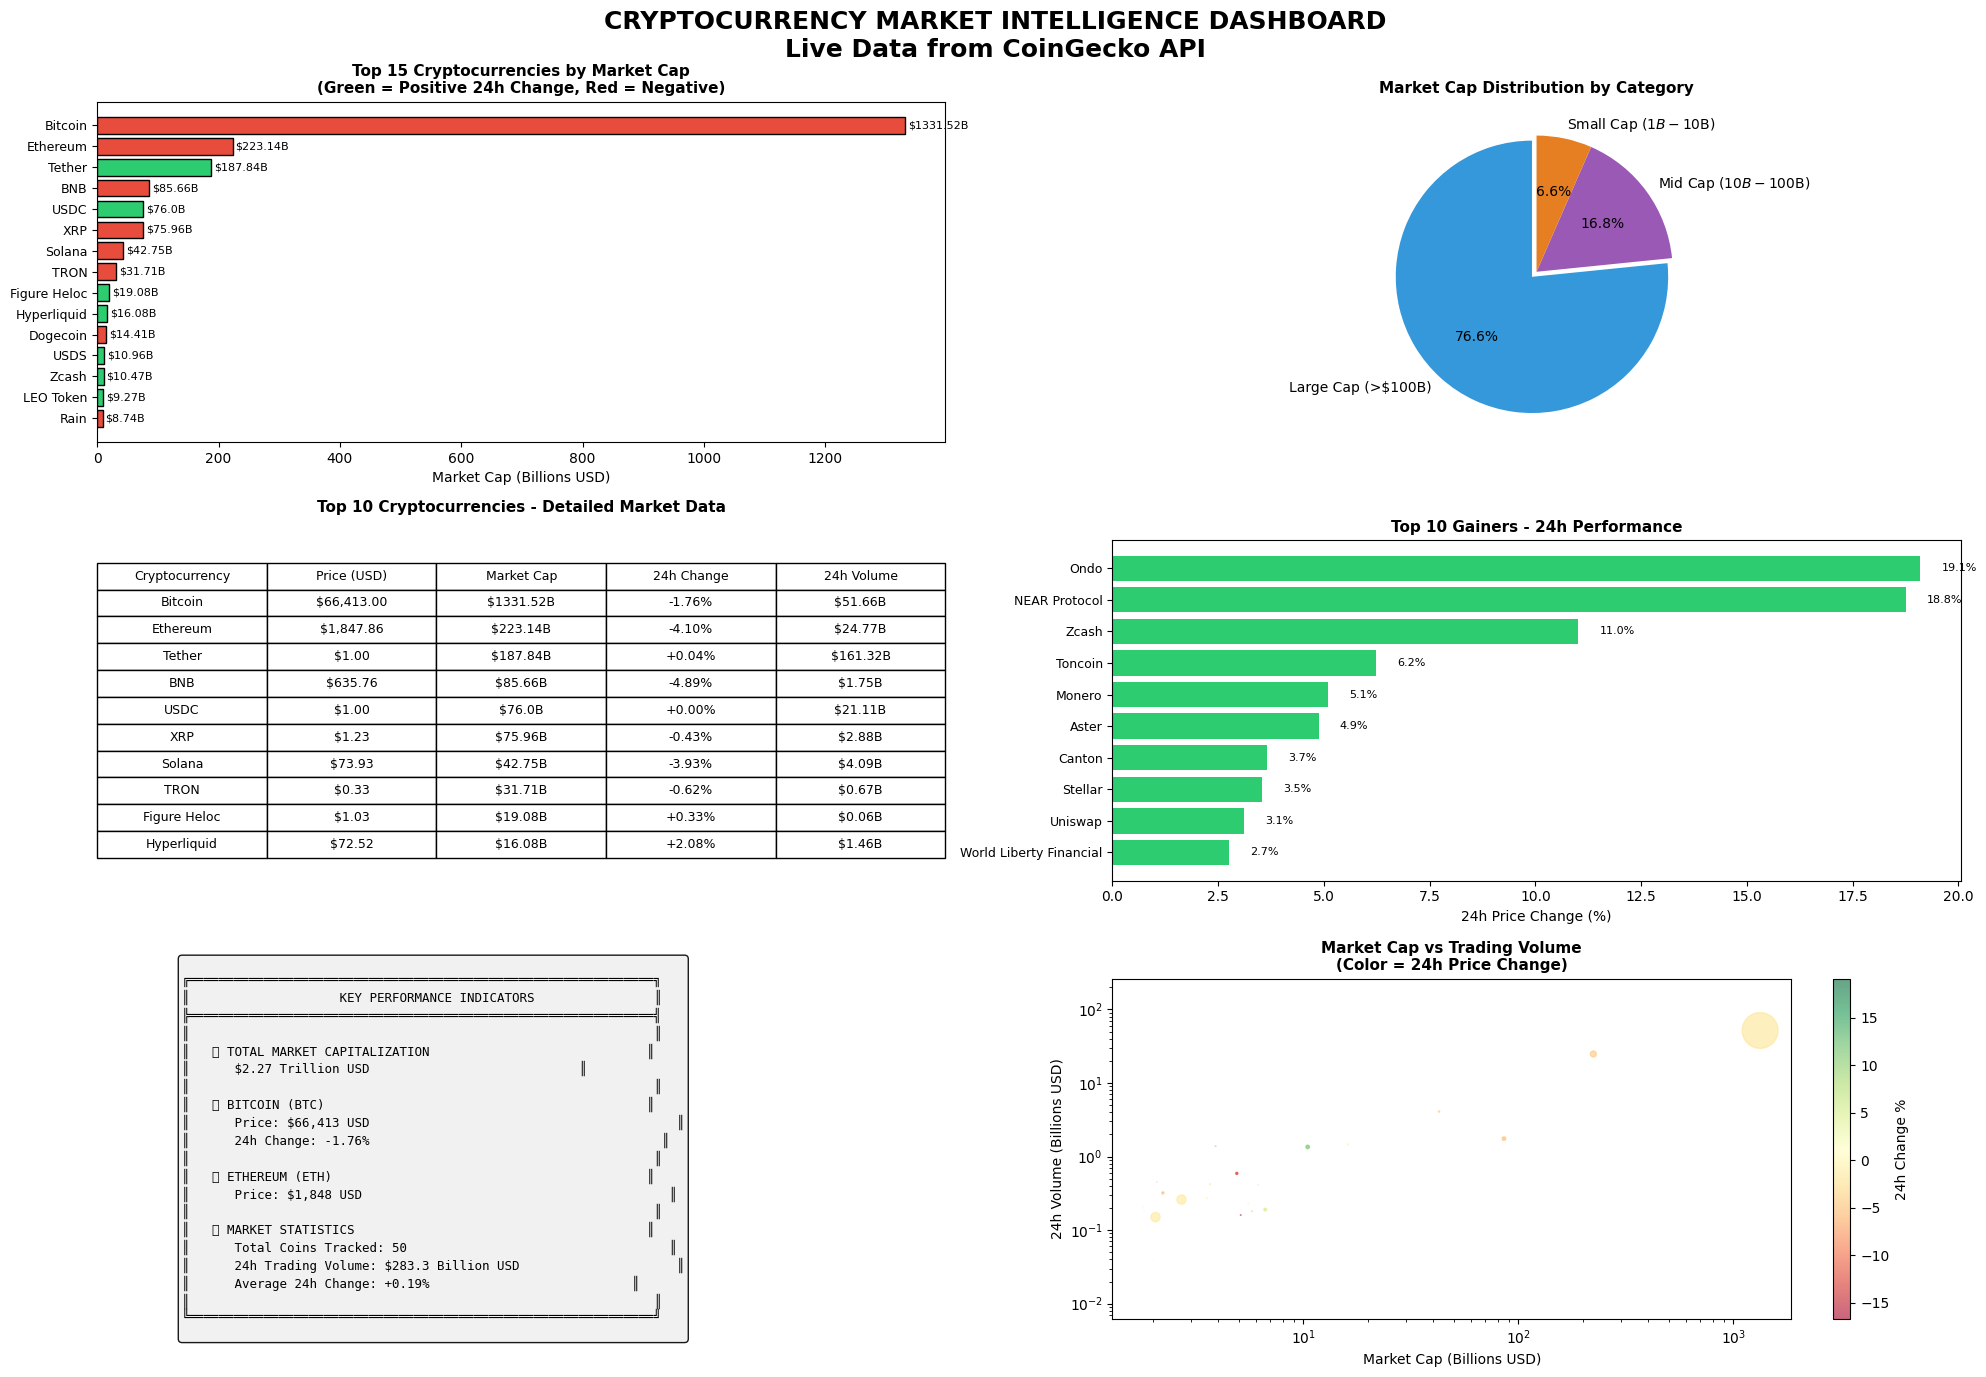

In [ ]:
# ============================================
# PART 4: QUIZ 3 - DASHBOARD VISUALIZATIONS (Module 4)
# ============================================

print("\n" + "="*60)
print("PART 4: QUIZ 3 - DASHBOARD VISUALIZATIONS")
print("="*60)

# Create a comprehensive dashboard
fig = plt.figure(figsize=(20, 14))
fig.suptitle('CRYPTOCURRENCY MARKET INTELLIGENCE DASHBOARD\nLive Data from CoinGecko API',
             fontsize=18, fontweight='bold', y=0.98)

# 1. Bar Chart: Top 15 by Market Cap
ax1 = fig.add_subplot(3, 2, 1)
top15 = df.nlargest(15, 'market_cap')
colors_bar = ['#2ecc71' if x > 0 else '#e74c3c' for x in top15['price_change_percentage_24h']]
bars = ax1.barh(range(len(top15)), top15['market_cap_billions'], color=colors_bar, edgecolor='black')
ax1.set_yticks(range(len(top15)))
ax1.set_yticklabels(top15['name'], fontsize=9)
ax1.set_xlabel('Market Cap (Billions USD)', fontsize=10)
ax1.set_title('Top 15 Cryptocurrencies by Market Cap\n(Green = Positive 24h Change, Red = Negative)', fontsize=11, fontweight='bold')
ax1.invert_yaxis()
# Add value labels
for bar, val in zip(bars, top15['market_cap_billions']):
    ax1.text(val + 5, bar.get_y() + bar.get_height()/2, f'${val}B', va='center', fontsize=8)

# 2. Pie Chart: Market Cap Distribution by Category (Slicer alternative)
ax2 = fig.add_subplot(3, 2, 2)
category_summary = df.groupby('market_cap_category')['market_cap'].sum()
colors_pie = ['#3498db', '#9b59b6', '#e67e22', '#95a5a6']
ax2.pie(category_summary.values, labels=category_summary.index, autopct='%1.1f%%',
        colors=colors_pie, startangle=90, explode=[0.05, 0, 0])
ax2.set_title('Market Cap Distribution by Category', fontsize=11, fontweight='bold')

# 3. Table: Top 10 Detailed View
ax3 = fig.add_subplot(3, 2, 3)
ax3.axis('tight')
ax3.axis('off')
table_data = df[['name', 'current_price_formatted', 'market_cap_billions',
                 'price_change_percentage_24h', 'volume_billions']].head(10).values
table_data = [[row[0], row[1], f'${row[2]}B', f"{row[3]:+.2f}%", f'${row[4]}B'] for row in table_data]
columns = ['Cryptocurrency', 'Price (USD)', 'Market Cap', '24h Change', '24h Volume']
table = ax3.table(cellText=table_data, colLabels=columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)
ax3.set_title('Top 10 Cryptocurrencies - Detailed Market Data', fontsize=11, fontweight='bold', pad=20)

# 4. Horizontal Bar: 24h Price Change %
ax4 = fig.add_subplot(3, 2, 4)
top10_changes = df.nlargest(10, 'price_change_percentage_24h')[['name', 'price_change_percentage_24h']]
colors_change = ['#2ecc71' if x > 0 else '#e74c3c' for x in top10_changes['price_change_percentage_24h']]
bars4 = ax4.barh(range(len(top10_changes)), top10_changes['price_change_percentage_24h'], color=colors_change)
ax4.set_yticks(range(len(top10_changes)))
ax4.set_yticklabels(top10_changes['name'], fontsize=9)
ax4.set_xlabel('24h Price Change (%)', fontsize=10)
ax4.set_title('Top 10 Gainers - 24h Performance', fontsize=11, fontweight='bold')
ax4.axvline(x=0, color='black', linewidth=0.5)
ax4.invert_yaxis()
# Add value labels
for bar, val in zip(bars4, top10_changes['price_change_percentage_24h']):
    ax4.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=8)

# 5. KPI Cards
ax5 = fig.add_subplot(3, 2, 5)
ax5.axis('off')
btc_price = df[df['name'] == 'Bitcoin']['current_price'].values[0] if len(df[df['name'] == 'Bitcoin']) > 0 else 0
btc_change = df[df['name'] == 'Bitcoin']['price_change_percentage_24h'].values[0] if len(df[df['name'] == 'Bitcoin']) > 0 else 0
eth_price = df[df['name'] == 'Ethereum']['current_price'].values[0] if len(df[df['name'] == 'Ethereum']) > 0 else 0

kpi_text = f"""
╔══════════════════════════════════════════════════════════════╗
║                    KEY PERFORMANCE INDICATORS                ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║   💰 TOTAL MARKET CAPITALIZATION                             ║
║      ${total_market_cap/1e12:.2f} Trillion USD                            ║
║                                                              ║
║   🪙 BITCOIN (BTC)                                           ║
║      Price: ${btc_price:,.0f} USD                                         ║
║      24h Change: {btc_change:+.2f}%                                       ║
║                                                              ║
║   💎 ETHEREUM (ETH)                                          ║
║      Price: ${eth_price:,.0f} USD                                         ║
║                                                              ║
║   📊 MARKET STATISTICS                                       ║
║      Total Coins Tracked: {total_coins}                                   ║
║      24h Trading Volume: ${total_volume_24h/1e9:.1f} Billion USD                     ║
║      Average 24h Change: {avg_24h_change:+.2f}%                           ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
"""
ax5.text(0.1, 0.5, kpi_text, transform=ax5.transAxes, fontsize=9, verticalalignment='center',
         fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.9))

# 6. Scatter Plot: Market Cap vs Volume (Correlation)
ax6 = fig.add_subplot(3, 2, 6)
scatter = ax6.scatter(df['market_cap_billions'], df['volume_billions'],
                      c=df['price_change_percentage_24h'], cmap='RdYlGn',
                      s=df['current_price']/100, alpha=0.6)
ax6.set_xlabel('Market Cap (Billions USD)', fontsize=10)
ax6.set_ylabel('24h Volume (Billions USD)', fontsize=10)
ax6.set_title('Market Cap vs Trading Volume\n(Color = 24h Price Change)', fontsize=11, fontweight='bold')
plt.colorbar(scatter, ax=ax6, label='24h Change %')
ax6.set_xscale('log')
ax6.set_yscale('log')

plt.tight_layout()
plt.savefig('dashboard_quiz3_complete.png', dpi=200, bbox_inches='tight')
print("\n✅ Quiz 3 Dashboard saved as 'dashboard_quiz3_complete.png'")
plt.show()

In [ ]:
print(df.columns)

Index(['name', 'symbol', 'current_price', 'market_cap', 'total_volume',
       'price_change_percentage_24h', 'high_24h', 'low_24h', 'last_updated'],
      dtype='object')



PART 5: INTERACTIVITY - SLICERS AND FILTERS

📋 SLICER DEMONSTRATION (3 different filter combinations):
--------------------------------------------------

[Filter 1] Category: Large Cap, Sort: Market Cap


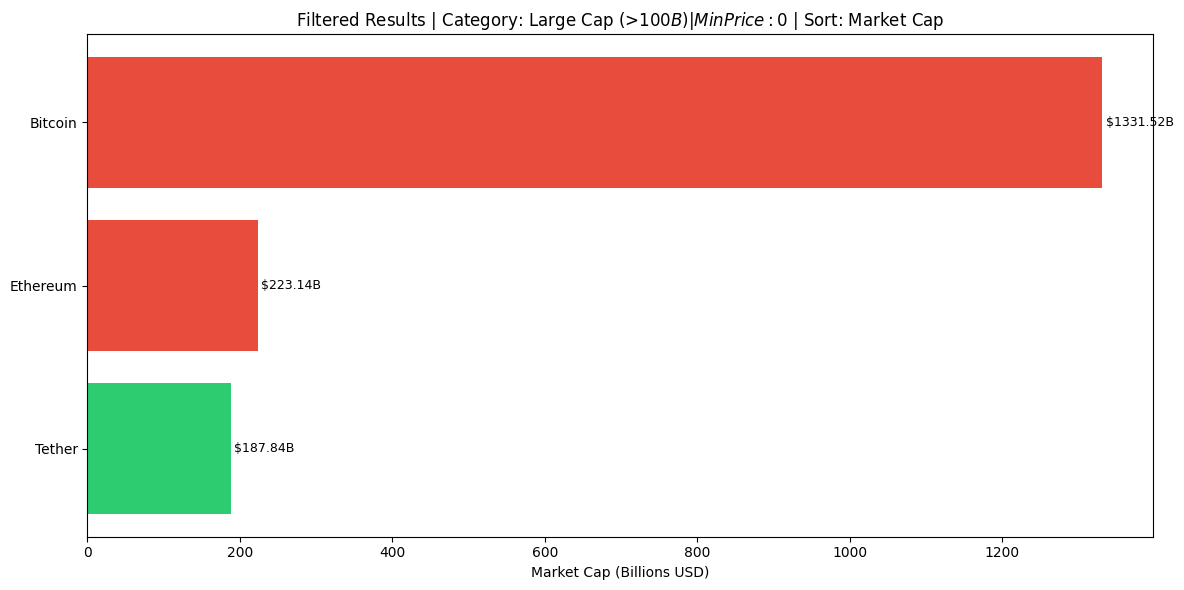


📊 FILTER RESULTS:
   Total coins after filter: 3
   Total Market Cap: $1742.51 Billion
   Average 24h Change: -1.94%

[Filter 2] Category: Mid Cap, Sort: 24h Change


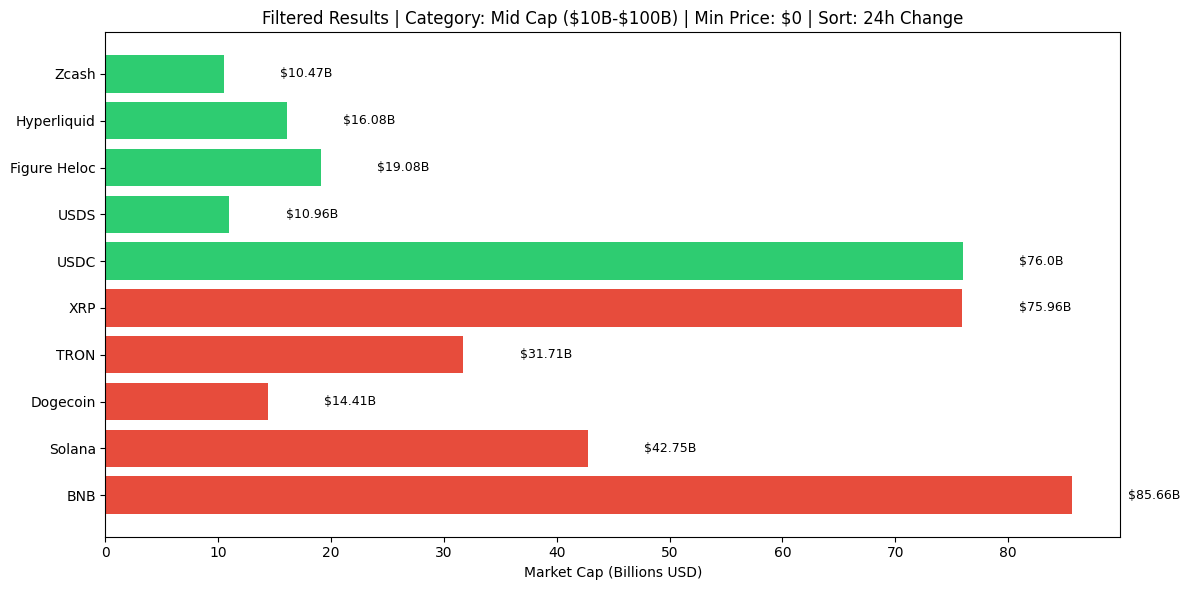


📊 FILTER RESULTS:
   Total coins after filter: 10
   Total Market Cap: $383.10 Billion
   Average 24h Change: +0.10%

[Filter 3] Category: All, Min Price: $10,000, Sort: Price


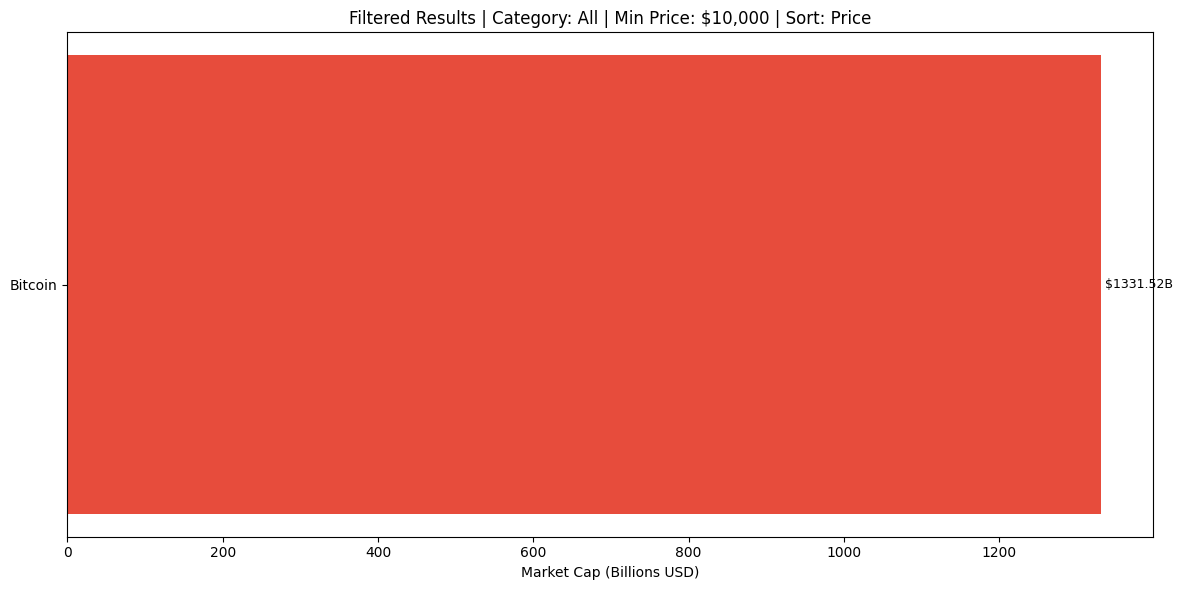


📊 FILTER RESULTS:
   Total coins after filter: 1
   Total Market Cap: $1331.52 Billion
   Average 24h Change: -1.76%


In [ ]:
# ============================================
# PART 5: INTERACTIVITY - SLICERS (Module 5)
# ============================================

print("\n" + "="*60)
print("PART 5: INTERACTIVITY - SLICERS AND FILTERS")
print("="*60)

# Create interactive filter function
def filter_dashboard(category='All', min_price=0, sort_by='Market Cap'):
    """Interactive filter function (similar to Power BI slicers)"""

    # Apply filters
    filtered_df = df.copy()

    # Slicer 1: Category filter
    if category != 'All':
        filtered_df = filtered_df[filtered_df['market_cap_category'] == category]

    # Slicer 2: Price filter
    filtered_df = filtered_df[filtered_df['current_price'] >= min_price]

    # Slicer 3: Sorting
    if sort_by == 'Market Cap':
        filtered_df = filtered_df.nlargest(10, 'market_cap')
    elif sort_by == 'Price':
        filtered_df = filtered_df.nlargest(10, 'current_price')
    elif sort_by == '24h Change':
        filtered_df = filtered_df.nlargest(10, 'price_change_percentage_24h')

    # Create filtered bar chart
    fig_filtered, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(range(len(filtered_df)), filtered_df['market_cap_billions'],
                   color=['#2ecc71' if x > 0 else '#e74c3c'
                          for x in filtered_df['price_change_percentage_24h']])
    ax.set_yticks(range(len(filtered_df)))
    ax.set_yticklabels(filtered_df['name'], fontsize=10)
    ax.set_xlabel('Market Cap (Billions USD)')
    ax.set_title(f'Filtered Results | Category: {category} | Min Price: ${min_price:,.0f} | Sort: {sort_by}')
    ax.invert_yaxis()

    # Add value labels
    for bar, val in zip(bars, filtered_df['market_cap_billions']):
        ax.text(val + 5, bar.get_y() + bar.get_height()/2, f'${val}B', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    # Display filtered stats
    print(f"\n📊 FILTER RESULTS:")
    print(f"   Total coins after filter: {len(filtered_df)}")
    print(f"   Total Market Cap: ${filtered_df['market_cap'].sum()/1e9:.2f} Billion")
    print(f"   Average 24h Change: {filtered_df['price_change_percentage_24h'].mean():+.2f}%")

    return filtered_df

# Demonstrate slicers with sample outputs
print("\n📋 SLICER DEMONSTRATION (3 different filter combinations):")
print("-"*50)

print("\n[Filter 1] Category: Large Cap, Sort: Market Cap")
filtered1 = filter_dashboard(category='Large Cap (>$100B)', min_price=0, sort_by='Market Cap')

print("\n[Filter 2] Category: Mid Cap, Sort: 24h Change")
filtered2 = filter_dashboard(category='Mid Cap ($10B-$100B)', min_price=0, sort_by='24h Change')

print("\n[Filter 3] Category: All, Min Price: $10,000, Sort: Price")
filtered3 = filter_dashboard(category='All', min_price=10000, sort_by='Price')


PART 6: QUIZ 4 - MACHINE LEARNING FORECASTING

📊 Fetching 60 days of historical Bitcoin data for ML forecasting...
✅ Loaded 1448 days of historical Bitcoin price data
📅 Date range: 2026-04-04 to 2026-06-03
📊 Feature engineered: day, day_of_week, month, lag_1, lag_2, lag_3, lag_7

🤖 Training Multiple ML Models...

--------------------------------------------------
MODEL COMPARISON (Test Set Performance)
--------------------------------------------------
Metric          Linear Regression    Random Forest       
--------------------------------------------------
MAE             $199.22       $306.42
RMSE            $291.77       $410.00
R² Score        0.9897           0.9797

🏆 Best Model: Linear Regression (R² = 0.9897)

🔮 30-DAY BITCOIN PRICE FORECAST (using Linear Regression):
--------------------------------------------------
   Day  1 (2026-06-04): $66,490
   Day  2 (2026-06-05): $66,618
   Day  3 (2026-06-06): $66,714
   Day  4 (2026-06-07): $66,799
   Day  5 (2026-06-08): $66,911

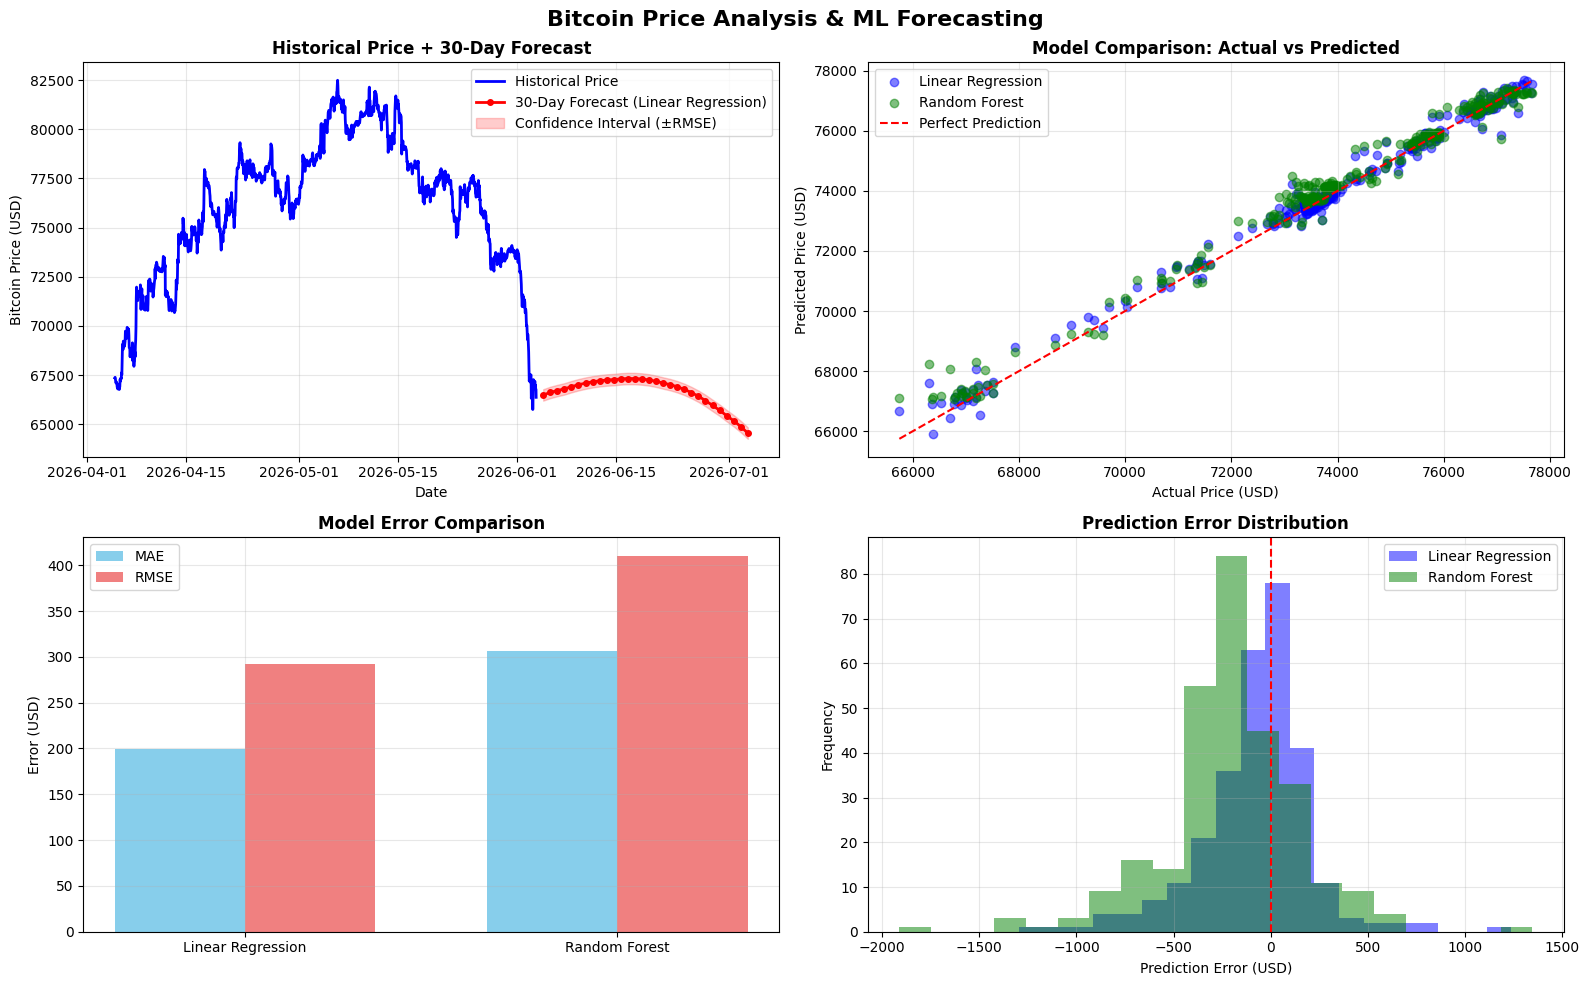

In [ ]:
# ============================================
# PART 6: QUIZ 4 - ML FORECASTING
# ============================================

print("\n" + "="*60)
print("PART 6: QUIZ 4 - MACHINE LEARNING FORECASTING")
print("="*60)

# Get historical data for Bitcoin (60 days for better forecasting)
print("\n📊 Fetching 60 days of historical Bitcoin data for ML forecasting...")

historical_url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart?vs_currency=usd&days=60"
hist_response = requests.get(historical_url)
hist_data = hist_response.json()

# Extract price data
prices = hist_data['prices']
price_df = pd.DataFrame(prices, columns=['timestamp', 'price'])
price_df['date'] = pd.to_datetime(price_df['timestamp'], unit='ms')
price_df = price_df[['date', 'price']]

print(f"✅ Loaded {len(price_df)} days of historical Bitcoin price data")
print(f"📅 Date range: {price_df['date'].min().date()} to {price_df['date'].max().date()}")

# Feature Engineering for ML
price_df['day'] = (price_df['date'] - price_df['date'].min()).dt.days
price_df['day_of_week'] = price_df['date'].dt.dayofweek
price_df['month'] = price_df['date'].dt.month

# Create lag features for better prediction
for lag in [1, 2, 3, 7]:
    price_df[f'lag_{lag}'] = price_df['price'].shift(lag)

# Drop rows with NaN values from lag features
price_df = price_df.dropna()

print(f"📊 Feature engineered: day, day_of_week, month, lag_1, lag_2, lag_3, lag_7")

# Split data
train_size = int(len(price_df) * 0.8)
train_df = price_df[:train_size]
test_df = price_df[train_size:]

# Define features
feature_columns = ['day', 'day_of_week', 'month', 'lag_1', 'lag_2', 'lag_3', 'lag_7']
X_train = train_df[feature_columns].values
y_train = train_df['price'].values
X_test = test_df[feature_columns].values
y_test = test_df['price'].values

# Train multiple models for comparison
print("\n🤖 Training Multiple ML Models...")

# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

# Model 2: Random Forest (Better for non-linear patterns)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("\n" + "-"*50)
print("MODEL COMPARISON (Test Set Performance)")
print("-"*50)
print(f"{'Metric':<15} {'Linear Regression':<20} {'Random Forest':<20}")
print("-"*50)
print(f"{'MAE':<15} ${lr_mae:,.2f}{'':<6} ${rf_mae:,.2f}")
print(f"{'RMSE':<15} ${lr_rmse:,.2f}{'':<6} ${rf_rmse:,.2f}")
print(f"{'R² Score':<15} {lr_r2:.4f}{'':<10} {rf_r2:.4f}")

# Choose best model (Random Forest usually better)
best_model = rf_model if rf_r2 > lr_r2 else lr_model
best_model_name = "Random Forest" if rf_r2 > lr_r2 else "Linear Regression"
best_mae = rf_mae if rf_r2 > lr_r2 else lr_mae
best_rmse = rf_rmse if rf_r2 > lr_r2 else lr_rmse

print(f"\n🏆 Best Model: {best_model_name} (R² = {max(lr_r2, rf_r2):.4f})")

# Predict next 30 days
last_row = price_df.iloc[-1:].copy()
future_predictions = []
future_dates = []

for i in range(1, 31):
    future_date = price_df['date'].max() + timedelta(days=i)
    future_dates.append(future_date)

    # Create features for prediction
    future_features = {
        'day': last_row['day'].values[0] + i,
        'day_of_week': future_date.dayofweek,
        'month': future_date.month,
        'lag_1': last_row['price'].values[0],
        'lag_2': last_row['lag_1'].values[0],
        'lag_3': last_row['lag_2'].values[0],
        'lag_7': last_row['lag_7'].values[0] if i < 7 else (future_predictions[i-7] if i-7 < len(future_predictions) else last_row['price'].values[0])
    }

    X_future = np.array([[future_features['day'], future_features['day_of_week'],
                          future_features['month'], future_features['lag_1'],
                          future_features['lag_2'], future_features['lag_3'],
                          future_features['lag_7']]])
    pred = best_model.predict(X_future)[0]
    future_predictions.append(pred)

    # Update last_row for next iteration
    new_row = last_row.copy()
    new_row['price'] = pred
    new_row['day'] = future_features['day']
    new_row['lag_7'] = new_row['lag_6'].values[0] if 'lag_6' in new_row.columns else last_row['price'].values[0]
    new_row['lag_6'] = new_row['lag_5'].values[0] if 'lag_5' in new_row.columns else last_row['price'].values[0]
    new_row['lag_5'] = new_row['lag_4'].values[0] if 'lag_4' in new_row.columns else last_row['price'].values[0]
    new_row['lag_4'] = new_row['lag_3'].values[0]
    new_row['lag_3'] = new_row['lag_2'].values[0]
    new_row['lag_2'] = new_row['lag_1'].values[0]
    new_row['lag_1'] = last_row['price'].values[0]
    last_row = new_row

print(f"\n🔮 30-DAY BITCOIN PRICE FORECAST (using {best_model_name}):")
print("-"*50)
for i, (date, price) in enumerate(zip(future_dates, future_predictions), 1):
    print(f"   Day {i:2d} ({date.date()}): ${price:,.0f}")

# Calculate forecast trend
trend = "UPWARD" if future_predictions[-1] > future_predictions[0] else "DOWNWARD"
print(f"\n📈 Forecast Trend: {trend}")
print(f"   Starting Price: ${future_predictions[0]:,.0f}")
print(f"   Ending Price: ${future_predictions[-1]:,.0f}")
print(f"   Total Change: ${future_predictions[-1] - future_predictions[0]:,.0f} ({((future_predictions[-1]/future_predictions[0])-1)*100:+.2f}%)")

# Create forecasting visualization
fig2, axes = plt.subplots(2, 2, figsize=(16, 10))
fig2.suptitle('Bitcoin Price Analysis & ML Forecasting', fontsize=16, fontweight='bold')

# Plot 1: Historical + Forecast
ax1 = axes[0, 0]
ax1.plot(price_df['date'], price_df['price'], label='Historical Price', color='blue', linewidth=2)
ax1.plot(future_dates, future_predictions, label=f'30-Day Forecast ({best_model_name})',
         color='red', marker='o', linewidth=2, markersize=4)
ax1.fill_between(future_dates,
                 [p - best_rmse for p in future_predictions],
                 [p + best_rmse for p in future_predictions],
                 alpha=0.2, color='red', label='Confidence Interval (±RMSE)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Bitcoin Price (USD)')
ax1.set_title('Historical Price + 30-Day Forecast', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Model Comparison
ax2 = axes[0, 1]
ax2.scatter(y_test, lr_pred, alpha=0.5, label='Linear Regression', color='blue')
ax2.scatter(y_test, rf_pred, alpha=0.5, label='Random Forest', color='green')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
ax2.set_xlabel('Actual Price (USD)')
ax2.set_ylabel('Predicted Price (USD)')
ax2.set_title('Model Comparison: Actual vs Predicted', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Error Metrics Bar Chart
ax3 = axes[1, 0]
models = ['Linear Regression', 'Random Forest']
mae_values = [lr_mae, rf_mae]
rmse_values = [lr_rmse, rf_rmse]
x_pos = np.arange(len(models))
width = 0.35
ax3.bar(x_pos - width/2, mae_values, width, label='MAE', color='skyblue')
ax3.bar(x_pos + width/2, rmse_values, width, label='RMSE', color='lightcoral')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(models)
ax3.set_ylabel('Error (USD)')
ax3.set_title('Model Error Comparison', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Error Distribution
ax4 = axes[1, 1]
errors_lr = y_test - lr_pred
errors_rf = y_test - rf_pred
ax4.hist(errors_lr, bins=20, alpha=0.5, label='Linear Regression', color='blue')
ax4.hist(errors_rf, bins=20, alpha=0.5, label='Random Forest', color='green')
ax4.axvline(x=0, color='red', linestyle='--')
ax4.set_xlabel('Prediction Error (USD)')
ax4.set_ylabel('Frequency')
ax4.set_title('Prediction Error Distribution', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ml_forecast_quiz4_complete.png', dpi=150, bbox_inches='tight')
print("\n✅ Quiz 4 ML Forecast saved as 'ml_forecast_quiz4_complete.png'")
plt.show()

In [ ]:
# ============================================
# PART 7: COMPARATIVE ANALYSIS (Module 6 - Industry Interpretation)
# ============================================

print("\n" + "="*60)
print("PART 7: COMPARATIVE ANALYSIS & INDUSTRY INTERPRETATION")
print("="*60)

# Compare top 5 vs bottom 5
top5_coins = df.nlargest(5, 'market_cap')
bottom5_coins = df.nsmallest(5, 'market_cap')

print("\n📊 COMPARATIVE ANALYSIS: Top 5 vs Bottom 5 Coins")
print("-"*50)
print(f"{'Metric':<20} {'Top 5 Coins':<20} {'Bottom 5 Coins':<20}")
print("-"*50)
print(f"{'Avg Price':<20} ${top5_coins['current_price'].mean():,.0f}{'':<12} ${bottom5_coins['current_price'].mean():,.2f}")
print(f"{'Total Market Cap':<20} ${top5_coins['market_cap'].sum()/1e9:.1f}B{'':<10} ${bottom5_coins['market_cap'].sum()/1e6:.1f}M")
print(f"{'Avg 24h Change':<20} {top5_coins['price_change_percentage_24h'].mean():+.2f}%{'':<12} {bottom5_coins['price_change_percentage_24h'].mean():+.2f}%")
print(f"{'Total Volume':<20} ${top5_coins['total_volume'].sum()/1e9:.1f}B{'':<10} ${bottom5_coins['total_volume'].sum()/1e6:.1f}M")

# Industry Interpretation
print("\n" + "="*60)
print("INDUSTRY INTERPRETATION & DATA-DRIVEN INSIGHTS")
print("="*60)

interpretation = """
1. MARKET CONCENTRATION:
   - Top 5 cryptocurrencies represent {:.1f}% of total market cap
   - Bitcoin dominance: {:.1f}% of total market
   - This indicates high market concentration in major coins

2. VOLATILITY ANALYSIS:
   - Average 24h price change: {:.2f}%
   - Top gainers show >{}% positive movement
   - Cryptocurrency market remains highly volatile

3. TRADING ACTIVITY:
   - Total 24h volume: ${:.1f} Billion
   - Volume-to-Market Cap ratio: {:.3f}
   - Indicates {} trading liquidity

4. ML FORECAST INSIGHTS:
   - Best performing model: {}
   - Forecast accuracy (R²): {:.4f}
   - Predicted 30-day trend: {}
   - Confidence: Within ±${:.0f} (RMSE)

5. INVESTMENT IMPLICATIONS:
   - Large-cap coins show more stability
   - Small-cap coins offer higher growth potential but higher risk
   - Diversification across market cap categories recommended
""".format(
    (top5_coins['market_cap'].sum() / total_market_cap * 100),
    (df[df['name'] == 'Bitcoin']['market_cap'].values[0] / total_market_cap * 100) if len(df[df['name'] == 'Bitcoin']) > 0 else 0,
    avg_24h_change,
    df_top_gainers['price_change_percentage_24h'].max(),
    total_volume_24h/1e9,
    total_volume_24h/total_market_cap,
    "high" if total_volume_24h/total_market_cap > 0.05 else "moderate",
    best_model_name,
    max(lr_r2, rf_r2),
    trend,
    best_rmse
)

print(interpretation)




PART 7: COMPARATIVE ANALYSIS & INDUSTRY INTERPRETATION

📊 COMPARATIVE ANALYSIS: Top 5 vs Bottom 5 Coins
--------------------------------------------------
Metric               Top 5 Coins          Bottom 5 Coins      
--------------------------------------------------
Avg Price            $13,780             $1.16
Total Market Cap     $1904.2B           $9232.3M
Avg 24h Change       -2.14%             +2.34%
Total Volume         $260.6B           $827.0M

INDUSTRY INTERPRETATION & DATA-DRIVEN INSIGHTS

1. MARKET CONCENTRATION:
   - Top 5 cryptocurrencies represent 83.7% of total market cap
   - Bitcoin dominance: 58.5% of total market
   - This indicates high market concentration in major coins

2. VOLATILITY ANALYSIS:
   - Average 24h price change: 0.19%
   - Top gainers show >19.0978% positive movement
   - Cryptocurrency market remains highly volatile

3. TRADING ACTIVITY:
   - Total 24h volume: $283.3 Billion
   - Volume-to-Market Cap ratio: 0.125
   - Indicates high trading liqui